In [28]:
import numpy as np
import pandas as pd
import matplotlib as plt
import keras
from keras.callbacks import LambdaCallback
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.optimizers import RMSprop
import lyricsgenius as genius
from scipy import stats
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re
import sys
import random
import os

Genius API key required
- search for artist 
- save artist's lyrics
    - this automatically creates a json file of lyrics

In [2]:
api = genius.Genius('KQ86NUTX0ust_fg7dGcY4d9nY5rOwEgafolgIJr69svsfZBpMTwOFOUKiKoocQMb')

In [3]:
artist = api.search_artist('LCD Soundsystem')
lyrics = artist.save_lyrics()

Searching for songs by LCD Soundsystem...

Song 1: "1New York, I Love You But You're Bringing me Down"
Song 2: "45:33 Intro (live at madison square garden)"
Song 3: "45:33 (Part 1)"
Song 4: "45:33 (Part 2)"
Song 5: "45:33 (Part 3)"
Song 6: "45:33 (Part 4)"
Song 7: "45:33 (Part 5)"
Song 8: "45:33 (Part 6)"
Song 9: "All I Want"
Song 10: "​all i want (live at madison square garden)"
Song 11: "All I Want (London Session)"
Song 12: "All My Friends"
Song 13: "All My Friends (Franz Ferdinand Version)"
Song 14: "All My Friends (John Cale's Version)"
Song 15: "​all my friends (live at madison square garden)"
Song 16: "All My Friends (London Session)"
Song 17: "All My Friends - Radio Edit"
Song 18: "​​american dream"
Song 19: "Beat Connection"
Song 20: "Beat Connection (disco dub version)"
Song 21: "Beat Connection (Extended Disco dub)"
Song 22: "Big Ideas"
"Big Ideas (Babytalk remix)" does not contain lyrics. Rejecting.
Song 23: "​​black screen"
Song 24: "Bye Bye Bayou (A Capella Version)"
Song

In [4]:
artist.songs[0]

("1New York, I Love You But You're Bringing me Down", 'LCD Soundsystem')

### Cleaning Lyrics

In [5]:
df = pd.DataFrame([[x.title,x.album,x.year,x.lyrics,x.writer_artists] for x in artist.songs])
df.columns = ['title', 'album','year','lyrics','writer']
df = df.dropna()

# make all album names and song titles lowercase
df['title'] = df['title'].str.lower()
df['album'] = df['album'].str.lower()

albums_wanted = ['45:33', 'this is happening', 'sound of silver', 'american dream', 
                 'lcd soundsystem', 'electric lady sessions']

df = df[df['album'].isin(albums_wanted)]

#there are no null lyrics but instrumentals should be excluded 
df = df[pd.notnull(df['lyrics'])]
print(df.shape)
df = df[~df.lyrics.str.contains("strumental")]

# Feature Engineering
# Derive text related metrics (number of characters, words, lines, unique words) and lexical density for each song.

# characters, words, lines
df['#characters'] = df.lyrics.str.len()
df['#words'] = df.lyrics.str.split().str.len()
df['#lines'] = df.lyrics.str.split('\n').str.len()
df['#uniq_words'] = df.lyrics.apply(lambda x: len(set(x.split())))
df['lexical_density'] = df['#uniq_words'] / df['#words']


#removing new line
df = df.replace(r'\\n',' ', regex=True)
df = df.replace('\n',' ', regex=True)


(46, 5)


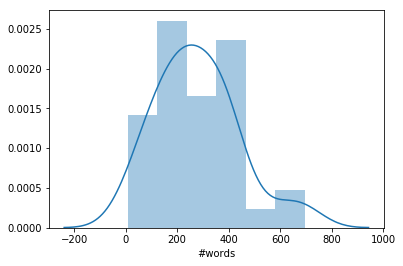

In [6]:
sns.distplot(df['#words']);

### LDA

In [7]:
# Topic modelling with LDA 
lyrics = pd.DataFrame(df["lyrics"])
# removing anything between square brackets ex [Verse 2]
lyrics["lyrics"] = lyrics['lyrics'].str.replace('\[.*\]','')
lyrics["lyrics"] = lyrics['lyrics'].str.replace('[^\w\s]','')

In [8]:
cVect = CountVectorizer(lowercase=True, tokenizer=None, stop_words=None, token_pattern = r"(?u)\b\w+\b")
dtmLyrics = cVect.fit_transform(lyrics["lyrics"]) 

In [10]:
lda = LatentDirichletAllocation(n_components=10, random_state=0)
X = lda.fit_transform(dtmLyrics.toarray()) 

In [11]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic %d:" % (topic_idx))
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
tf_feature_names = cVect.get_feature_names()
display_topics(lda, tf_feature_names, no_top_words)

Topic 0:
the well your then man he wanna aint see i
Topic 1:
the on i me and to come repeat you your
Topic 2:
drunk girls oh the boys in i believe waking up
Topic 3:
pow the it you and are a of these to
Topic 4:
you i the im want my but know was really
Topic 5:
hide were saved safe shame moment eyes x5 starry doot
Topic 6:
a you citys your sucker what ha to i want
Topic 7:
them up set never my house you got ooh to
Topic 8:
you we the and dont is it be need this
Topic 9:
yeah and the beat nobodys it in everybody youre hey


-------
Which song has the most unique words?
<br>
Which song has the least unique words?

In [12]:
maximum = df.loc[df['#uniq_words'].idxmax()]
minimum = df.loc[df['#uniq_words'].idxmin()]
print("Max: ",maximum["title"], " - ", maximum["#uniq_words"])
print("Min: ",minimum["title"], " - ", minimum["#uniq_words"])

Max:  losing my edge  -  294
Min:  tired  -  9


### Text Generation using LSTM

In [13]:
df['#characters'].sum()
# https://github.com/keras-team/keras/blob/master/examples/lstm_text_generation.py suggests to have ~ 100k characters
# if I included the duplicate songs I would probably have 100k...

52851

In [14]:
all_lyrics = [x.lyrics for x in artist.songs]

cleaned_lyrics = []
length = 0
for song in all_lyrics:
    if 'Instrumental' not in song:
        temp = song
        temp = temp.replace('\n',' ')
        temp = temp.replace('\[.*\]','')
        temp = re.sub(r'[^\w\s]','',temp)
        temp = temp.lower()
        cleaned_lyrics.extend([temp])
        length += len(temp.strip())

print("Characters: ", length)

full = " ".join(cleaned_lyrics)

Characters:  171851


In [15]:
# now each song is an element within cleaned_lyrics
chars = sorted(list(set(full)))
print('total chars:', len(chars))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

total chars: 38


In [16]:
# cut the text in semi-redundant sequences of maxlen characters
maxlen = 40
step = 3
sentences = []
next_chars = []
for i in range(0, len(full) - maxlen, step):
    sentences.append(full[i: i + maxlen])
    next_chars.append(full[i + maxlen])
print('nb sequences:', len(sentences))


nb sequences: 57310


In [17]:
print('Vectorization...')
x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
y = np.zeros((len(sentences), len(chars)), dtype=np.bool)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

Vectorization...


In [26]:
# build the model: a single LSTM
print('Build model...')
model = Sequential()
model.add(LSTM(128, input_shape=(maxlen, len(chars))))
model.add(Dense(len(chars), activation='softmax'))

optimizer = RMSprop(lr=0.01)
model.compile(loss='categorical_crossentropy', optimizer=optimizer)


def sample(preds, temperature=1.0):
    # helper function to sample an index from a probability array
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def on_epoch_end(epoch, _):
    # Function invoked at end of each epoch. Prints generated text.
    print()
    print('----- Generating text after Epoch: %d' % epoch)

    start_index = random.randint(0, len(full) - maxlen - 1)
    for diversity in [0.2, 0.5, 1.0, 1.2]:
        print('----- diversity:', diversity)

        generated = ''
        sentence = full[start_index: start_index + maxlen]
        generated += sentence
        print('----- Generating with seed: "' + sentence + '"')
        sys.stdout.write(generated)

        for i in range(400):
            x_pred = np.zeros((1, maxlen, len(chars)))
            for t, char in enumerate(sentence):
                x_pred[0, t, char_indices[char]] = 1.

            preds = model.predict(x_pred, verbose=0)[0]
            next_index = sample(preds, diversity)
            next_char = indices_char[next_index]

            generated += next_char
            sentence = sentence[1:] + next_char

            sys.stdout.write(next_char)
            sys.stdout.flush()
        print()

print_callback = LambdaCallback(on_epoch_end=on_epoch_end)

Build model...


In [32]:
model.fit(x, y,
          batch_size=128,
          epochs=30,
          callbacks=[print_callback])

Epoch 1/30
57310/57310 [==============================] - 31s 537us/step - loss: 0.4857

----- Generating text after Epoch: 0
----- diversity: 0.2
----- Generating with seed: "ng any play its the saddest night out in"
ng any play its the saddest night out in the usa its the saddest nights and soun in the kids ameright 

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:14: RuntimeWarning: divide by zero encountered in log
  


to the back of that what were nore wishing the songer and the police bler on call of starts come what im was im wasting me home with what we hane it oh stupid me imprown and the reall crying to be filling in nobodys last than the shove wishing the shopen  open where were from the engy and the night oh shut until the day comes a little b
----- diversity: 0.5
----- Generating with seed: "ng any play its the saddest night out in"
ng any play its the saddest night out in the usa in the usa its me impisith me make your hand you wake what you make me far away frimule show you the ropes kid show you the ropes kid show you the ropes kid show you to wake we are north american scum oh we are north american scum were from north american scum where the bable plarer on a couple of the hasy one to way its the saddest night out in the usa its the saddest night sound crush y
----- diversity: 1.0
----- Generating with seed: "ng any play its the saddest night out in"
ng any play its the saddest night ou

-----
This iteration of this project is generating a blob of text that isn't really structured like song lyrics.
Often the generated lyrics are very repetitive but LCD Sound System's music is very repetitive...

Future work
- adding in song structure (verses, chorus etc)
- possible adding in rhyming using https://pypi.org/project/pronouncing/, which could generate variations from words not seen.
- running for longer ~60 epoch